# Testing the LSTM Model

### GPU Availability Test

In [1]:
import tensorflow as tf
print("\n\nNum GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-08-22 22:51:36.662080: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-22 22:51:36.888458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755903097.032364   25085 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755903097.070035   25085 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-22 22:51:37.344906: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr



Num GPUs Available:  1


### Test Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
test_df = pd.read_csv("Prepared-Data/test-data.csv")
test_df

,Text,Ham,Spam
0,A enviar mensagens de texto a +351 XXX XXX XXX...,0,1
1,pela sua colaboracao Favor informar o numero c...,0,1
2,Ho ho - big belly laugh! See ya tomo,1,0
3,Ü bot notes oredi... Cos i juz rem i got...,1,0
4,Get XX off upto Rs.300 at Grofers use your RBL...,0,1
...,...,...,...
9363,martes XX de octubre de XXXX MAS INFORMACION X...,0,1
9364,"CJIB Uw openstaande schuld van EUR € 42,00 mee...",0,1
9365,Lieber Kunde Aufgrund einer allgemeinen Datenk...,0,1
9366,by SMSCaster.com Apple Your Apple Pay have be ...,0,1


### Importing Models and Predicting results

In [4]:
vectorizer = tf.keras.models.load_model("Models/Vectorizer-Models/spam_ham_text_vectorizer_2.keras")
vectorizer

I0000 00:00:1755903115.896968   25085 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


<TextVectorization name=text_vectorization, built=True>

In [5]:
model = tf.keras.models.load_model("Models/Predictive-Models/spam_ham_BiLstm_2.keras")
model

<Sequential name=sequential_1, built=True>

In [7]:
vectorized_text = vectorizer(test_df['Text'].values)
vectorized_text

<tf.Tensor: shape=(9368, 1070), dtype=int64, numpy=
array([[    6,  1132, 17782, ...,     0,     0,     0],
       [ 3837,   789,  6609, ...,     0,     0,     0],
       [ 1216,  1216,   601, ...,     0,     0,     0],
       ...,
       [ 9014,  3374, 23855, ...,     0,     0,     0],
       [   50,     1,   695, ...,     0,     0,     0],
       [ 1863,     4,    42, ...,     0,     0,     0]])>

In [8]:
result_arr = model.predict(vectorized_text)
result_arr

I0000 00:00:1755903138.474493   25236 cuda_dnn.cc:529] Loaded cuDNN version 90300


293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step


array([[1.5865940e-23, 1.0000000e+00],
       [9.9979449e-15, 1.0000000e+00],
       [1.0000000e+00, 1.0578362e-10],
       ...,
       [9.4807796e-17, 1.0000000e+00],
       [7.3584016e-21, 1.0000000e+00],
       [1.7174278e-17, 1.0000000e+00]], dtype=float32)

In [9]:
predictions = (result_arr > 0.5).astype('int')
predictions

array([[0, 1],
       [0, 1],
       [1, 0],
       ...,
       [0, 1],
       [0, 1],
       [0, 1]])

In [10]:
actual_values = test_df[test_df.columns[1:]].values
actual_values

array([[0, 1],
       [0, 1],
       [1, 0],
       ...,
       [0, 1],
       [0, 1],
       [0, 1]])

In [11]:
accuracy = (predictions == actual_values).mean()

print(f"Model Accuracy: {accuracy * 100} %")

Model Accuracy: 97.53949615713066 %


## Result Evaluations

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [13]:
spam_true = test_df["Spam"].values
spam_pred = [pred[1] for pred in predictions] # Getting spam from predictions, (it was in index 1)

In [14]:
accuracy_score(spam_true, spam_pred)

0.9754483347566183

Text(77.92222222222227, 0.5, 'Actual Values')

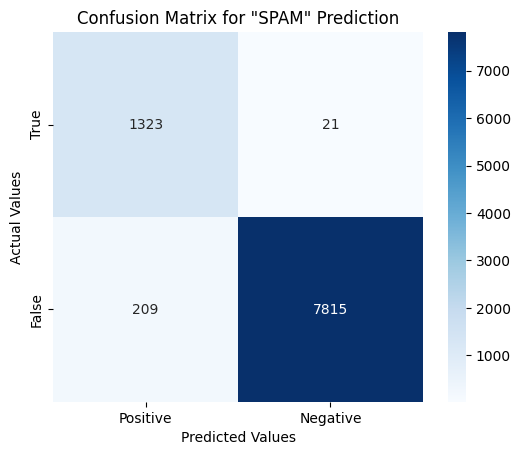

In [16]:
cfm = confusion_matrix(spam_true, spam_pred)

sns.heatmap(
    cfm, 
    annot=True, 
    cmap='Blues',
    fmt='.4g',
    square=True, 
    xticklabels=["Positive", "Negative"],
    yticklabels=["True", "False"],
)
plt.title('Confusion Matrix for "SPAM" Prediction')
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

In [18]:
print(classification_report(spam_true, spam_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1344
           1       1.00      0.97      0.99      8024

    accuracy                           0.98      9368
   macro avg       0.93      0.98      0.95      9368
weighted avg       0.98      0.98      0.98      9368



## Done!!
- Hence our **Long Short Term Memory (LSTM)** Models provides around ***97.54%*** accuracy on Test Dataset.